In [1]:
import numpy as np

def model_A(arr,arr_T):
    arr=arr*2
    tss = sum((arr_T - np.mean(arr_T))**2) 
    rss = sum((arr_T-arr)**2)
    return arr,(arr-arr_T),(arr_T-arr)**2,sum((arr_T-arr)**2),sum((arr_T-arr)**2)/arr.shape,(sum((arr_T-arr)**2)/arr.shape)**0.5,1-(rss/tss)

def model_B(arr,arr_T):
    arr=arr+2
    tss = sum((arr_T - np.mean(arr_T))**2) 
    rss = sum((arr_T-arr)**2)
    return arr,(arr-arr_T),(arr_T-arr)**2,sum((arr_T-arr)**2),sum((arr_T-arr)**2)/arr.shape,(sum((arr_T-arr)**2)/arr.shape)**0.5,1-(rss/tss)


arr = np.array([1,2,3,4,5,6,7,8,9,10])
arr_T = np.array([2,4,5,5,6,7,12,15,18,20])

print(model_A(arr,arr_T))
print(model_B(arr,arr_T))



(array([ 2,  4,  6,  8, 10, 12, 14, 16, 18, 20]), array([0, 0, 1, 3, 4, 5, 2, 1, 0, 0]), array([ 0,  0,  1,  9, 16, 25,  4,  1,  0,  0]), np.int64(56), array([5.6]), array([2.36643191]), np.float64(0.8463227222832053))
(array([ 3,  4,  5,  6,  7,  8,  9, 10, 11, 12]), array([ 1,  0,  0,  1,  1,  1, -3, -5, -7, -8]), array([ 1,  0,  0,  1,  1,  1,  9, 25, 49, 64]), np.int64(151), array([15.1]), array([3.88587185]), np.float64(0.5856201975850713))


Model A is the best fit.<br>15*2=30 ====> price = $3000K

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# For building the model and evaluate it 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics  # metrics like R2 , MSE , RSS , TSS , RMSE , MAE

# Set a style for plots
sns.set_style('whitegrid')

In [3]:
df = pd.read_csv('advertising.csv')
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [4]:
is_null = df.isna()
is_unique = df.duplicated()
print(is_null.sum(),f'Duplicates : {is_unique.sum()}',sep='\n')

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64
Duplicates : 0


In [5]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


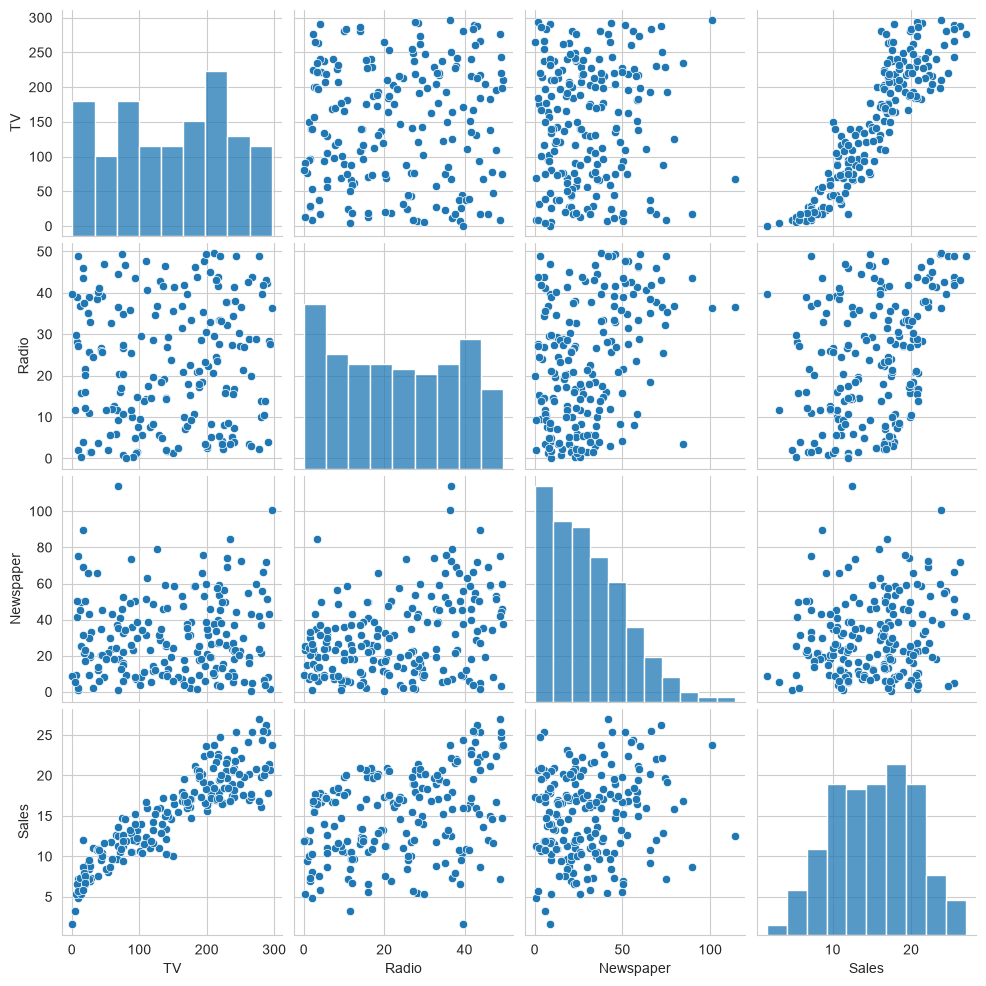

In [6]:
sns.pairplot(df)
plt.show()

In [7]:
X = df[['TV']] #scikit learn expects a 2D array 
y = df['Sales']
print(X.shape)
print(y.shape) 

(200, 1)
(200,)


In [8]:
X_train , X_test , y_train , y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'training set shape : {X_train.shape}')
print(f'testing set shape : {X_test.shape}')

training set shape : (160, 1)
testing set shape : (40, 1)


In [9]:
simple_model = LinearRegression()
simple_model.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.06]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['TV']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,7.007
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [10]:
print(f'Bias (intercept) : {simple_model.intercept_:.4f}')
print(f'Coefficient (slope) : {simple_model.coef_[0]:.4f}')

Bias (intercept) : 7.0071
Coefficient (slope) : 0.0555


In [14]:
print(f'b : {simple_model.intercept_:.4f}')
print(f'w : {simple_model.coef_[0]:.4f}')

b : 7.0071
w : 0.0555


In [12]:
y_train_predict = simple_model.predict(X_train)
y_test_predict = simple_model.predict(X_test)

print(f'RMSE_train : {metrics.root_mean_squared_error(y_train,y_train_predict)}')
print(f'RMSE_test : {metrics.root_mean_squared_error(y_test,y_test_predict)}')

print(f'MAE_train : {metrics.mean_absolute_error(y_train,y_train_predict)}')
print(f'MAE_test : {metrics.mean_absolute_error(y_test,y_test_predict)}')

print(f'R2_train : {metrics.r2_score(y_train,y_train_predict)}')
print(f'R2_test : {metrics.r2_score(y_test,y_test_predict)}')

RMSE_train : 2.235719650683013
RMSE_test : 2.470035001123256
MAE_train : 1.8005092256620792
MAE_test : 1.9502948931650088
R2_train : 0.8134866044709264
R2_test : 0.802561303423698


RMSE is compare with respective to range of distribution.

<img src='Screenshot 2026-08-30 090334.png'>

<img src='Screenshot 2026-08-30 091616.png'>

<img src='Screenshot 2026-08-30 093748.png'>

<img src='Screenshot 2026-08-30 094114.png'>
<img src='Screenshot 2026-08-30 111645.png'>
<img src='Screenshot 2026-08-30 112257.png'>
<img src='Screenshot 2026-08-30 114142.png'>
<img src='Screenshot 2026-08-30 151910.png'>
<img src='Screenshot 2026-08-30 152520.png'>
<img src='Screenshot 2026-08-30 152629.png'>
<img src='Screenshot 2026-08-30 153048.png'>
<img src='Screenshot 2026-08-30 161615.png'>